In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

Load 1977–2026 Data

In [2]:
files = glob.glob("BoxOffice_CSV_Data/*.csv")

dataframes = []

for file in files:
    temp = pd.read_csv(file)

    year = int(
        os.path.basename(file)
        .split('_')[-1]
        .replace('.csv', '')
    )

    temp['year'] = year
    dataframes.append(temp)

df = pd.concat(dataframes, ignore_index=True)

df.head()

,date,occasion,top10_gross,top10_wow_change,overall_gross,overall_wow_change,num_releases,top_release,week_no,year
0,"Dec 30-Jan 2, 1978",New Year's long wknd,-,-,-,-,-,-,52,1977
1,"Dec 30-Jan 1, 1978",NaN,-,-,-,-,-,-,52,1977
2,Dec 23-26,Christmas long wknd,"$5,564,559",-,"$5,564,559",-,2,Close Encounters of the Third Kind,51,1977
3,Dec 23-25,NaN,-,-,-,-,-,-,51,1977
4,Dec 16-18,NaN,"$10,102,221",+776.2%,"$10,102,221",+776.2%,3,Close Encounters of the Third Kind,50,1977


Remove duplicates

In [4]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape:", df.shape)

Dataset shape: (2961, 10)


Clean Gross Columns

In [5]:
money_cols = ['top10_gross', 'overall_gross']

for col in money_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .replace('-', np.nan)
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

Clean Percentage Columns

In [6]:
pct_cols = ['top10_wow_change', 'overall_wow_change']

for col in pct_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .replace('-', np.nan)
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

Clean Releases + Occasion

In [7]:
df['num_releases'] = pd.to_numeric(
    df['num_releases'],
    errors='coerce'
)

df['occasion'] = df['occasion'].fillna(
    'No Special Occasion'
)

Visualization Overview

# Data Visualization

This project visualizes historical weekend box-office data from 1977 to 2026.

The visualizations focus on:
- Yearly box-office trends
- Highest-grossing years
- Top movie releases
- Special occasions
- Number of releases and overall gross
- Week-over-week changes
- Box-office distribution and outliers

Yearly Box Office Trend

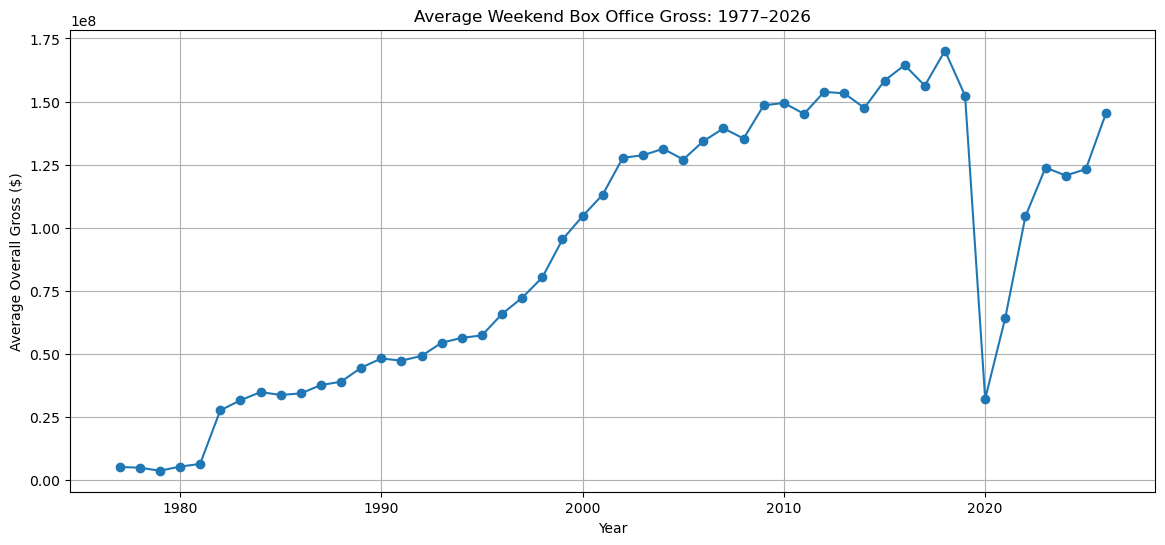

In [8]:
yearly_gross = (
    df.groupby('year')['overall_gross']
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    yearly_gross.index,
    yearly_gross.values,
    marker='o'
)

plt.title('Average Weekend Box Office Gross: 1977–2026')
plt.xlabel('Year')
plt.ylabel('Average Overall Gross ($)')
plt.grid(True)

plt.show()

## Insight

This visualization shows the change in average weekend box-office revenue across the years 1977 to 2026. It helps identify long-term growth, decline and unusual periods.

Top 10 Years

In [10]:
top_years = (
    df.groupby('year')['overall_gross']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_years

year
2018    1.701345e+08
2016    1.644456e+08
2015    1.582855e+08
2017    1.562816e+08
2012    1.538278e+08
2013    1.532676e+08
2019    1.523779e+08
2010    1.494509e+08
2009    1.485145e+08
2014    1.474602e+08
Name: overall_gross, dtype: float64

Top 10 Years Chart

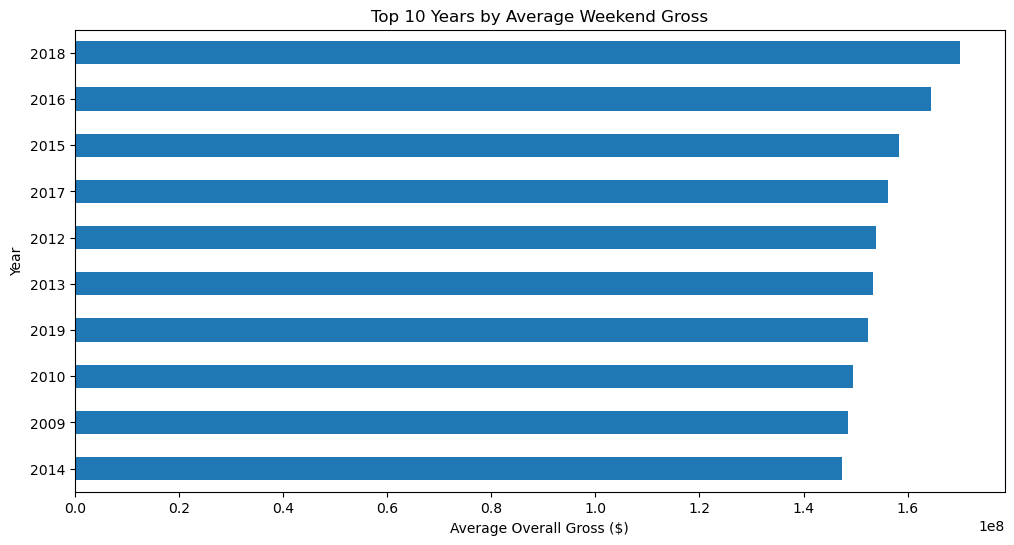

In [11]:
plt.figure(figsize=(12, 6))

top_years.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Years by Average Weekend Gross')
plt.xlabel('Average Overall Gross ($)')
plt.ylabel('Year')

plt.show()

## Insight

The chart highlights the years with the highest average weekend box-office revenue in the dataset.

Top Releases

In [12]:
top_movies = (
    df.groupby('top_release')['overall_gross']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_movies

top_release
Titanic                                      1.531591e+09
Avatar                                       1.438091e+09
Moana 2                                      1.265671e+09
Black Panther                                1.250203e+09
Star Wars: Episode VIII - The Last Jedi      1.163343e+09
Avatar: The Way of Water                     1.110447e+09
The Twilight Saga: Breaking Dawn - Part 2    1.106834e+09
Rogue One: A Star Wars Story                 1.101123e+09
Aquaman                                      1.085310e+09
National Treasure: Book of Secrets           1.009767e+09
Name: overall_gross, dtype: float64

Top Releases Chart

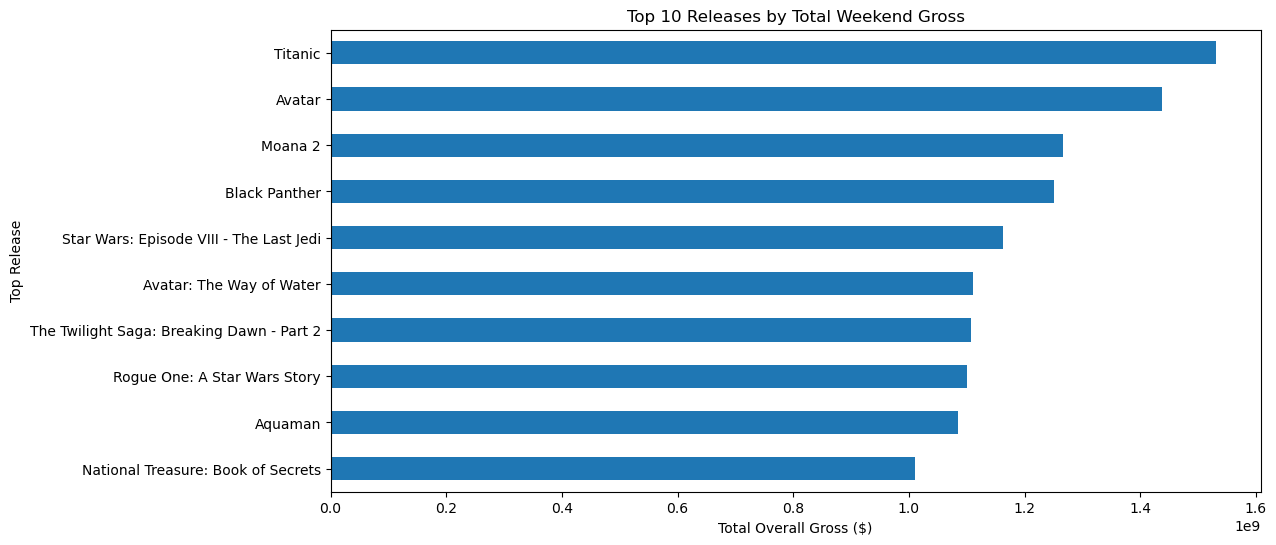

In [13]:
plt.figure(figsize=(12, 6))

top_movies.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Releases by Total Weekend Gross')
plt.xlabel('Total Overall Gross ($)')
plt.ylabel('Top Release')

plt.show()

## Insight

This visualization identifies the releases associated with the highest cumulative weekend box-office gross in the dataset.

Special Occasion Analysis

In [14]:
occasion_analysis = (
    df[df['occasion'] != 'No Special Occasion']
    .groupby('occasion')['overall_gross']
    .mean()
    .sort_values(ascending=False)
)

occasion_analysis.head(10)

occasion
Presidents' Day wkndPyeongChang Olympics      3.460756e+08
July 4th long wkndWorld Cup (South Africa)    2.504084e+08
Presidents' Day wkndVancouver Olympics        2.393803e+08
Mayweather/Pacquiao Fight                     2.328734e+08
July 4th long wkndWorld Cup (Germany)         2.258862e+08
World Cup (Russia)                            2.165766e+08
Presidents' Day wkndSochi Olympics            2.087623e+08
PyeongChang Olympics                          2.079725e+08
World Cup (South Africa)                      1.792543e+08
Rio Olympics                                  1.777197e+08
Name: overall_gross, dtype: float64

## Occasion Chart

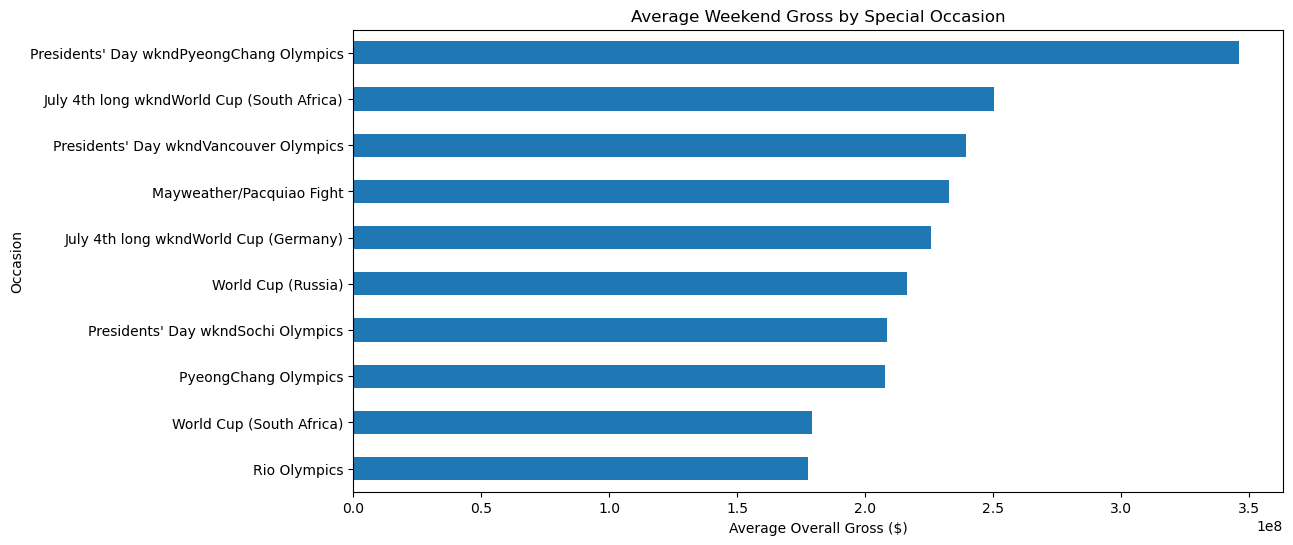

In [15]:
plt.figure(figsize=(12, 6))

occasion_analysis.head(10).sort_values().plot(
    kind='barh'
)

plt.title('Average Weekend Gross by Special Occasion')
plt.xlabel('Average Overall Gross ($)')
plt.ylabel('Occasion')

plt.show()

## Insight

The visualization compares average weekend box-office revenue during recorded special occasions and helps identify occasions associated with stronger performance.

Releases vs Overall Gross

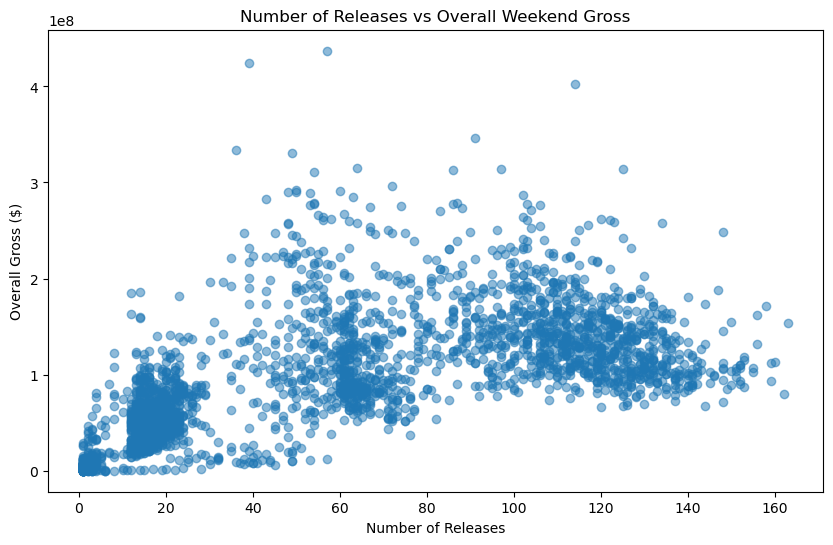

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['num_releases'],
    df['overall_gross'],
    alpha=0.5
)

plt.title('Number of Releases vs Overall Weekend Gross')
plt.xlabel('Number of Releases')
plt.ylabel('Overall Gross ($)')

plt.show()

## Insight

The scatter plot shows the relationship between the number of movie releases and overall weekend box-office revenue.

Week-over-Week Change

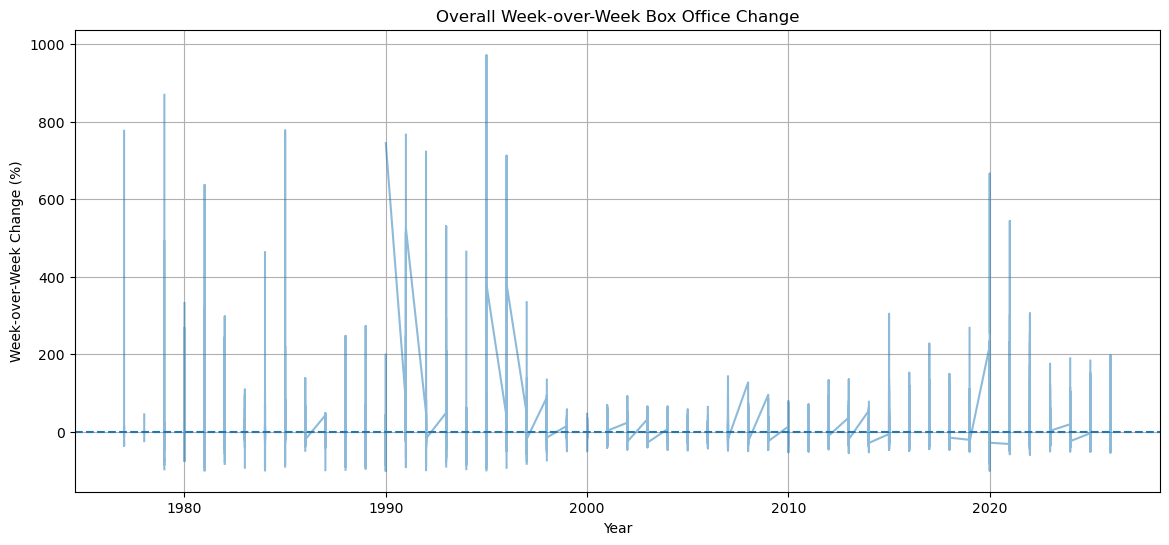

In [18]:
plt.figure(figsize=(14, 6))

plt.plot(
    df['year'],
    df['overall_wow_change'],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle='--'
)

plt.title('Overall Week-over-Week Box Office Change')
plt.xlabel('Year')
plt.ylabel('Week-over-Week Change (%)')
plt.grid(True)

plt.show()

## Insight

Positive values indicate an increase compared with the previous period, while negative values indicate a decline.

## Distribution of Overall Gross

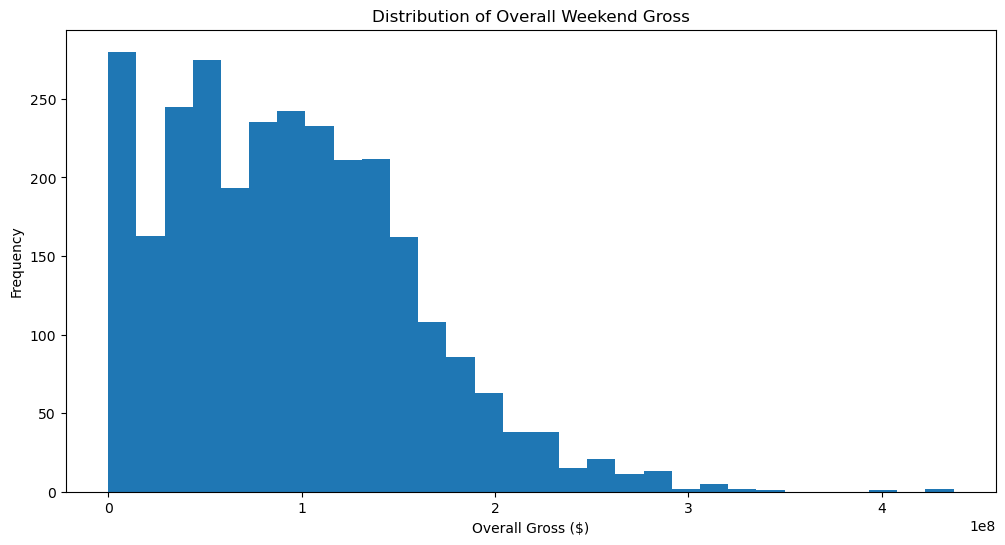

In [19]:
plt.figure(figsize=(12, 6))

plt.hist(
    df['overall_gross'].dropna(),
    bins=30
)

plt.title('Distribution of Overall Weekend Gross')
plt.xlabel('Overall Gross ($)')
plt.ylabel('Frequency')

plt.show()

## Insight

The histogram shows how frequently different levels of weekend box-office revenue occur in the dataset.

## Box Plot / Outliers

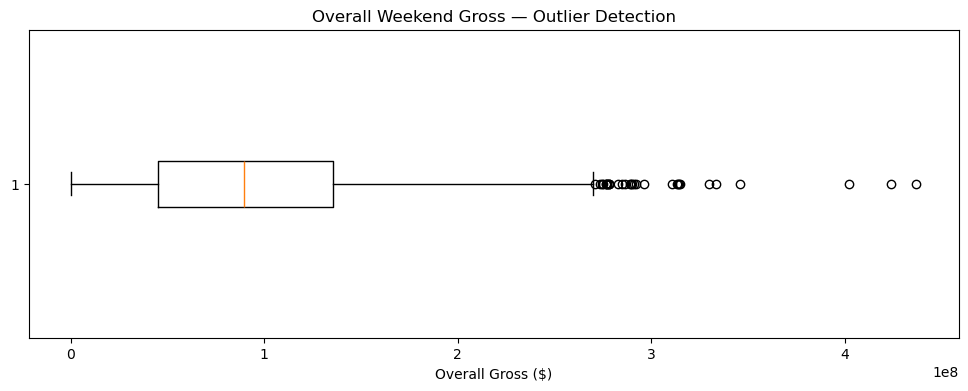

In [20]:
plt.figure(figsize=(12, 4))

plt.boxplot(
    df['overall_gross'].dropna(),
    vert=False
)

plt.title('Overall Weekend Gross — Outlier Detection')
plt.xlabel('Overall Gross ($)')

plt.show()

## Insight

The box plot helps identify unusually high or low weekend gross values that may represent exceptional box-office performances.

## Correlation Heatmap

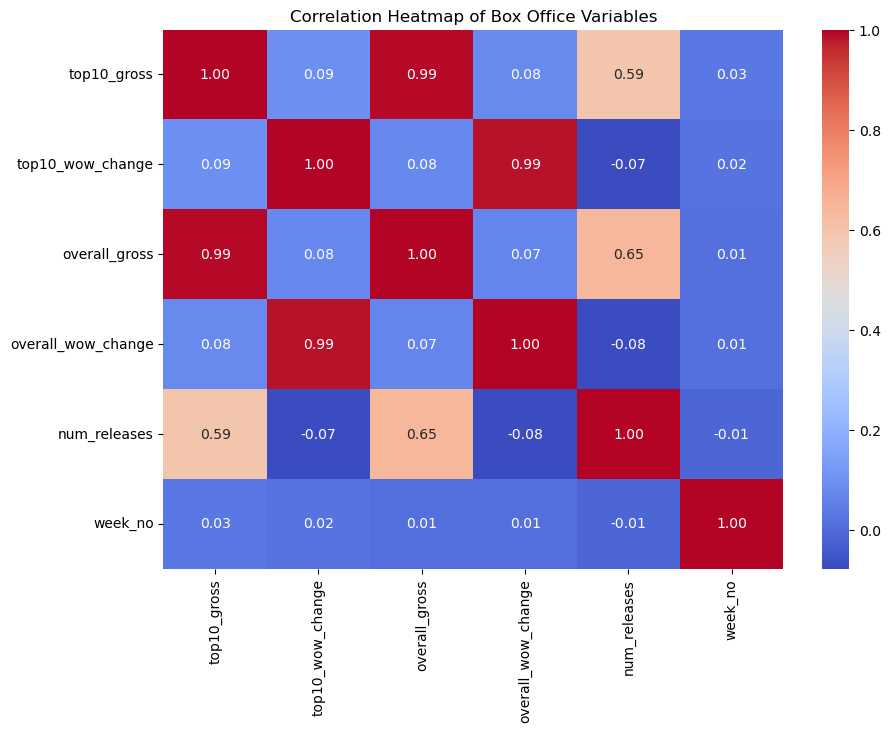

In [21]:
corr_cols = [
    'top10_gross',
    'top10_wow_change',
    'overall_gross',
    'overall_wow_change',
    'num_releases',
    'week_no'
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Box Office Variables')

plt.show()

## Insight

The correlation heatmap shows the strength and direction of relationships between numerical box-office variables.

## Highest Grossing Weekends

In [22]:
top_weekends = df.nlargest(
    10,
    'overall_gross'
)[
    [
        'date',
        'year',
        'overall_gross',
        'top_release'
    ]
]

top_weekends

,date,year,overall_gross,top_release
2926,Jul 31-Aug 2,2026,437130929.0,Spider-Man: Brand New Day
2803,Nov 27-Dec 1,2024,423943589.0,Moana 2
2529,Apr 26-28,2019,402087399.0,Avengers: Endgame
2480,Feb 16-19,2018,346075601.0,Black Panther
2802,Nov 28-Dec 1,2024,333484695.0,Moana 2
2893,May 23-26,2025,330174663.0,Lilo & Stitch
2436,Nov 21-25,2018,314861631.0,Ralph Breaks the Internet
2156,May 24-27,2013,314240056.0,Fast & Furious 6
2469,Apr 27-29,2018,313937789.0,Avengers: Infinity War
2241,Dec 18-20,2015,313284961.0,Star Wars: Episode VII - The Force Awakens


## Highest Week-over-Week Growth

In [23]:
highest_growth = df.nlargest(
    10,
    'overall_wow_change'
)[
    [
        'date',
        'year',
        'overall_wow_change',
        'top_release'
    ]
]

highest_growth

,date,year,overall_wow_change,top_release
200,May 1-3,1981,982.7,Friday the 13th: Part 2
1034,Sep 8-10,1995,971.2,"To Wong Foo, Thanks for Everything! Julie Newmar"
79,Oct 5-7,1979,869.1,10
112,Feb 9-11,1979,800.6,The Warriors
411,Oct 18-20,1985,777.2,Commando
4,Dec 16-18,1977,776.2,Close Encounters of the Third Kind
823,Jan 25-27,1991,766.2,Home Alone
767,Jan 5-7,1990,744.3,Born on the Fourth of July
883,Jan 24-26,1992,722.4,The Hand That Rocks the Cradle
1095,Sep 6-8,1996,712.1,Bulletproof


## Biggest Week-over-Week Declines

In [24]:
biggest_declines = df.nsmallest(
    10,
    'overall_wow_change'
)[
    [
        'date',
        'year',
        'overall_wow_change',
        'top_release'
    ]
]

biggest_declines

,date,year,overall_wow_change,top_release
2595,Mar 20-22,2020,-100.0,"Phoenix, OregonRe-release"
601,Sep 2-4,1988,-99.9,Rocket Gibraltar
165,Dec 25-27,1981,-99.5,On Golden Pond
723,Oct 5-7,1990,-99.4,Corporate Affairs
340,Dec 21-23,1984,-99.2,Ghostbusters
729,Aug 31-Sep 2,1990,-99.2,Total Recall
1068,Feb 17-19,1995,-99.0,Street Fighter
533,Oct 9-11,1987,-98.6,Man on Fire
760,Feb 16-18,1990,-98.6,Back to the Future Part II
510,Feb 14-16,1986,-98.5,Back to the Future


## Final Summary

## Key Visualization Findings

1. The yearly trend shows changes in average weekend box-office performance from 1977 to 2026.
2. Some years demonstrate substantially higher average weekend revenue than others.
3. Certain movie releases are associated with exceptionally strong box-office performance.
4. Special occasions can show differences in average weekend gross.
5. The scatter plot helps examine the relationship between the number of releases and overall gross.
6. Week-over-week visualization highlights periods of strong growth and decline.
7. The histogram and box plot show the distribution of box-office revenue and potential outliers.
8. The correlation heatmap provides an overview of relationships between numerical variables.

## Conclusion

Data visualization makes historical box-office data easier to understand by converting numerical information into clear charts and graphs. The visual analysis reveals trends, comparisons, relationships and unusual observations across the 1977–2026 period.